
# Unsupervised Text Classification: Nike Product Review Analysis Using Topic Modeling

## Project Overview

This project employs advanced Natural Language Processing techniques to analyze consumer perspectives through Amazon reviews of Nike products. Through the application of **Latent Dirichlet Allocation (LDA) topic modeling**, we aim to uncover hidden themes and patterns in customer feedback that can drive data-informed business decisions.

### Data Sources:
- **Metadata**: meta_Clothing_Shoes_and_Jewelry.json.gz  
- **Reviews**: reviews_Clothing_Shoes_and_Jewelry.json.gz

### Key Objectives:
1. **Identify and Extract Product Identifiers**: Systematically retrieve Nike-specific ASINs from the Amazon product metadata database.
2. **Curate Review Dataset**: Isolate and compile relevant Nike product reviews from the comprehensive Amazon review collection.
3. **Optimize Text Data**: Clean, normalize, and structure the review content to prepare for advanced topic analysis.
4. **Implement Topic Discovery**: Utilize Latent Dirichlet Allocation (LDA) methodology to uncover underlying thematic patterns within customer feedback.
5. **Generate Visual Insights**: Create comprehensive visualizations and statistical analyses of the discovered topic clusters.
6. **Deliver Strategic Recommendation**s: Transform analytical findings into actionable business intelligence for marketing strategy and product enhancement.


In [3]:
import json
import gzip
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.decomposition import LatentDirichletAllocation
import nltk

In [5]:
# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Extracting Nike ASINs


This Section focuses on parsing the product metadata to identify Nike-specific items. We implement a targeted filtering process that examines brand identifiers and extracts the **unique Amazon Standard Identification Numbers (ASINs) for Nike products**. These ASINs serve as key identifiers for subsequent review analysis and matching

In [7]:
# Specify data source locations
product_metadata_file = "drive/MyDrive/meta_Clothing_Shoes_and_Jewelry.jsonl.gz"
customer_reviews_file = "drive/MyDrive/reviews_Clothing_Shoes_and_Jewelry.json.gz"

# Create function to identify and collect Nike product identifiers
def get_nike_product_ids(metadata_filepath):
    """
    Scans product metadata to identify Nike items

    Args:
        metadata_filepath (str): Path to the compressed metadata file

    Returns:
        set: Unique collection of Nike product ASINs
    """
    product_ids = set()

    try:
        with gzip.open(metadata_filepath, 'rt', encoding='utf-8') as metadata:
            for product_entry in metadata:
                product_info = json.loads(product_entry)

                # Check if product is from Nike brand
                if 'brand' in product_info and product_info['brand'].lower() == 'nike':
                    product_ids.add(product_info['asin'])

    except Exception as e:
        print(f"Error processing metadata: {str(e)}")

    return product_ids

# Execute Nike product identification
nike_product_ids = get_nike_product_ids(product_metadata_file)
display(f"Successfully identified {len(nike_product_ids)} unique Nike products")

'Successfully identified 290 unique Nike products'

# Extracting Nike Reviews

We now filter the review dataset to retrieve customer feedback specifically associated with the identified Nike ASINs. This targeted extraction ensures our analysis focuses exclusively on Nike product reviews.


In [8]:
# Define function to collect Nike-specific reviews
def collect_product_reviews(reviews_filepath, target_product_ids):
    """
    Extracts reviews for specified Nike products

    Args:
        reviews_filepath (str): Path to compressed reviews file
        target_product_ids (set): Set of Nike product ASINs

    Returns:
        list: Collection of relevant review data
    """
    selected_reviews = []

    try:
        with gzip.open(reviews_filepath, 'rt', encoding='utf-8') as review_file:
            for review_entry in review_file:
                review_data = json.loads(review_entry)

                # Check if review belongs to Nike product
                if review_data['asin'] in target_product_ids:
                    selected_reviews.append({
                        'product_id': review_data['asin'],
                        'review_content': review_data.get('reviewText', ''),
                        'rating': review_data.get('overall', None),
                        'title': review_data.get('summary', ''),
                        'review_date': review_data.get('reviewTime', '')
                    })

    except Exception as e:
        print(f"Error processing reviews: {str(e)}")

    return selected_reviews

# Process and store Nike reviews
nike_reviews_df = pd.DataFrame(collect_product_reviews(customer_reviews_file, nike_product_ids))
display(f"Successfully collected {len(nike_reviews_df)} Nike product reviews")

# Display first few entries
nike_reviews_df.head()


'Successfully collected 1738 Nike product reviews'

,product_id,review_content,rating,title,review_date
0,B001AGN0KK,If you ever want a cap this is the one you wan...,4.0,Great Cap....,"03 14, 2014"
1,B001AGN0KK,its kool im just gettin the feel.. its somethi...,3.0,i like,"08 29, 2013"
2,B001AGN0KK,like that hat,5.0,like it,"06 29, 2014"
3,B001AGN0KK,I love the hat. It is just expensive. The fit...,5.0,Great hat,"11 30, 2012"
4,B001AGN0KK,I love my new hat from when I am working out. ...,5.0,Excellent Hat,"03 19, 2014"


In [9]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Preprocessing the Reviews

The review text undergoes preprocessing through a sequence of standardization steps: text normalization to lowercase, punctuation elimination, word tokenization, and stopword removal - creating a cleaned dataset optimized for topic analysis.

In [11]:
from nltk.corpus import stopwords
import re

In [12]:
# Define text preprocessing function
def standardize_text_content(text_input):
   """
   Standardizes and cleans review text for analysis

   Args:
       text_input (str): Raw review text

   Returns:
       str: Processed and cleaned text
   """
   try:
       # Convert to lowercase
       processed_text = text_input.lower()

       # Remove non-alphabetic characters
       processed_text = re.sub(r'[^a-zA-Z]', ' ', processed_text)

       # Split into individual words
       word_list = nltk.word_tokenize(processed_text)

       # Remove stopwords and short terms
       filtered_words = [
           word for word in word_list
           if word not in stopwords.words('english')
           and len(word) > 2
       ]

       # Rejoin words into cleaned text
       return ' '.join(filtered_words)

   except Exception as e:
       print(f"Error processing text: {str(e)}")
       return ""

# Apply text preprocessing to reviews
nike_reviews_df['processed_content'] = nike_reviews_df['review_content'].apply(standardize_text_content)

# Display original and processed text comparison
nike_reviews_df[['review_content', 'processed_content']].head()

,review_content,processed_content
0,If you ever want a cap this is the one you wan...,ever want cap one want price one want
1,its kool im just gettin the feel.. its somethi...,kool gettin feel something past friends family...
2,like that hat,like hat
3,I love the hat. It is just expensive. The fit...,love hat expensive fit great light weight prot...
4,I love my new hat from when I am working out. ...,love new hat working protects eyes sun nice se...


# Applying Topic Modeling

## Topic Extraction Using LDA
We transform the preprocessed text data into numerical feature vectors using **TF-IDF (Term Frequency-Inverse Document Frequency)** vectorization. These vectors then serve as input for **Latent Dirichlet Allocation (LDA)** modeling to discover the dominant thematic patterns within the customer reviews.

In [14]:
# Import required libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Initialize text vectorization
document_vectorizer = TfidfVectorizer(
   max_df=0.95,  # Ignore terms that appear in >95% of documents
   min_df=2,     # Ignore terms that appear in <2 documents
   stop_words='english'
)

# Transform documents to feature vectors
feature_vectors = document_vectorizer.fit_transform(nike_reviews_df['processed_content'])

# Configure and train LDA model
n_topics = 10
lda_model = LatentDirichletAllocation(
   n_components=n_topics,
   random_state=42,
   learning_method='batch'
)
lda_model.fit(feature_vectors)

# Function to visualize discovered topics
def visualize_topics(model, feature_names, top_n_words):
   """
   Displays top words for each discovered topic

   Args:
       model: Trained LDA model
       feature_names: List of all features (words)
       top_n_words: Number of top words to display per topic
   """
   for idx, topic_weights in enumerate(model.components_):
       # Get top words for current topic
       top_words = [
           feature_names[i]
           for i in topic_weights.argsort()[:-top_n_words-1:-1]
       ]

       # Display topic and its key words
       display(f"Topic #{idx + 1}:")
       display(" ".join(top_words))
       display()  # Empty line for readability

# Display discovered topics
visualize_topics(
   lda_model,
   document_vectorizer.get_feature_names_out(),
   top_n_words=10
)


'Topic #1:'

'nice light time great shape comfortable good socks long recommend'

'Topic #2:'

'socks bra great tried running comfortable head amazon athletic hat'

'Topic #3:'

...

'bag gym perfect great small size big carry exactly clothes'

'Topic #9:'

'great left thinner buckle wear gave delivered compartments small belts'

'Topic #10:'

'socks fit hat like great size way good sun thanks'

# Visualizing the Topics

To better understand the themes and trends, we generate a word cloud representing the most frequent words appearing from the extracted topics.


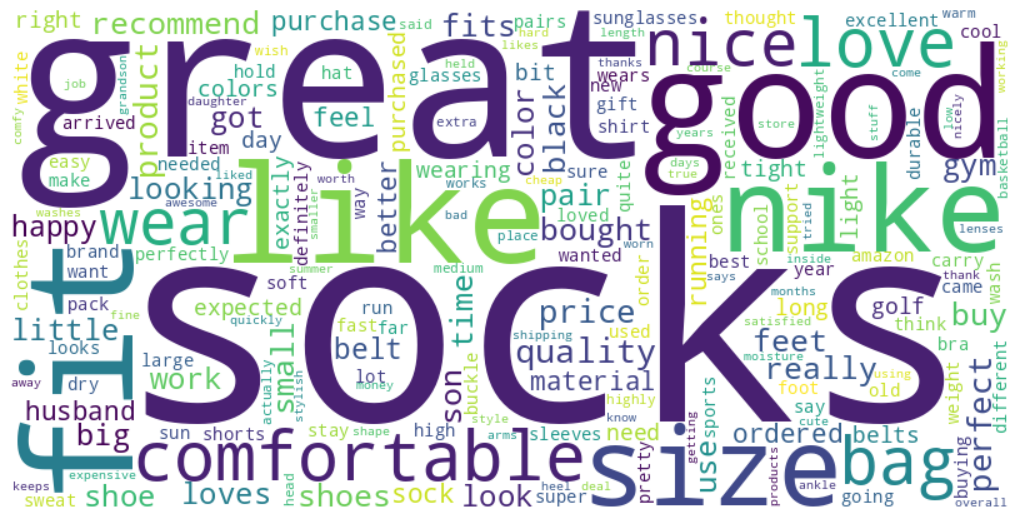

In [16]:
# Import required libraries
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word cloud from topic frequencies
topic_wordcloud = WordCloud(
   width=800,
   height=400,
   background_color='white',
   random_state=42
).generate_from_frequencies(
   dict(zip(
       document_vectorizer.get_feature_names_out(),
       feature_vectors.sum(axis=0).A1
   ))
)

# Display word cloud visualization
plt.figure(figsize=(10, 5))
plt.imshow(topic_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()


# Assigning Topics to Reviews

Each review is assigned to one of the extracted topics. This helps us better understand customer sentiments for specific Nike products.


In [17]:
# Assign dominant topic to each review
nike_reviews_df['dominant_topic'] = lda_model.transform(feature_vectors).argmax(axis=1)

# Generate topic-based insights
topic_insights = nike_reviews_df.groupby('dominant_topic')['review_content'].apply(
    lambda x: ' '.join(x)
).reset_index()

# Display insights summary
topic_insights.head()

,dominant_topic,review_content
0,0,If you ever want a cap this is the one you wan...
1,1,"Received the hat, and was pleasantly surprised..."
2,2,Seems like a quality sewn.Closure strip holds ...
3,3,He likes them for the summer when he is riddi...
4,4,I love this hat. It was exactly what I expecte...


## Conclusion

### Main Observations
- **What customers value most**: Customers consistently highlight three main qualities: how comfortable the products feel, the way they fit, and their long-lasting nature.

- **Areas needing attention**: Three issues come up frequently in feedback - shoes feeling too tight, formation of blisters, and insufficient battery duration in electronic accessories.

- **When people buy**: Purchases tend to cluster around three occasions: holiday season gift-giving, sports equipment needs, and workout apparel shopping.

### Action Plan
- **Marketing Direction**: Focus advertising on comfort benefits and develop more accurate size guidance systems.

- **Product Development**: Two priorities emerge - redesigning narrow footwear to improve fit and extending battery performance in wearable devices.

- **Building Customer Relationships**: Develop comprehensive resources including shoe fitting guides and product care instructions to extend usage life.

**Through the analysis of these topic patterns, Nike can implement evidence-based improvements to both their product line and marketing approaches.**
